In [1]:
import subprocess
import json


def run_oracle(params):
    """
    Inputs:
        double m_phi, double mA, double alpha, double beta, double lambda6, double lambda7, double m12
    Returns:
        Example Dictironary
        {'positivity_ok': 1, 'unitarity_ok': 0, 'perturbativity_ok': 0, 
        'w_h2_bb': 0.0, 'w_h2_tautau': 0.0, 'w_h2_WW': 0.0, 'w_h2_ZZ': 0.0, 
        'w_h2_gaga': 379.198422, 'w_h2_Zga': 48.375254, 'w_h2_gg': 0.0, 'w_h2_hh': 0.0, 
        'w_total_h2': 427.573676, 'branching_ratio_h2_gaga': 0.886861}

    """
    executable = "/home/ftrigo/DiHiggsWorking/dihiggs/app/Oracle" 
    cmd = [executable] + list(map(str, params))
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True)
    data = json.loads(result.stdout)
    return data

def brgaga(params):
    return run_oracle(params)["branching_ratio_h2_gaga"]


# Ejemplo de uso
params = [130.0, 150.0, 0.005, 1.57, 0.1, 0.1, 10.0]
output = run_oracle(params)
print(output)

# la funcion como tal
brgaga(params)

{'positivity_ok': 1, 'unitarity_ok': 0, 'perturbativity_ok': 0, 'w_h2_bb': 0.0, 'w_h2_tautau': 0.0, 'w_h2_WW': 0.0, 'w_h2_ZZ': 0.0, 'w_h2_gaga': 379.198422, 'w_h2_Zga': 48.375254, 'w_h2_gg': 0.0, 'w_h2_hh': 0.0, 'w_total_h2': 427.573676, 'branching_ratio_h2_gaga': 0.886861}


0.886861

# Graficos de paper
Este notebook toma los resultados de la evaluacion para crear los graficos en el mismo estilo que el paper de base

a) $\epsilon_V=0.1; \epsilon_A=0.1$
Lo que me lleva a $\alpha=0$, $\beta=0.09966\dots$

0.000195
0.000816
0.003693
0.05497
0.123919
0.232763
0.342804
0.468889
0.616926
0.790257


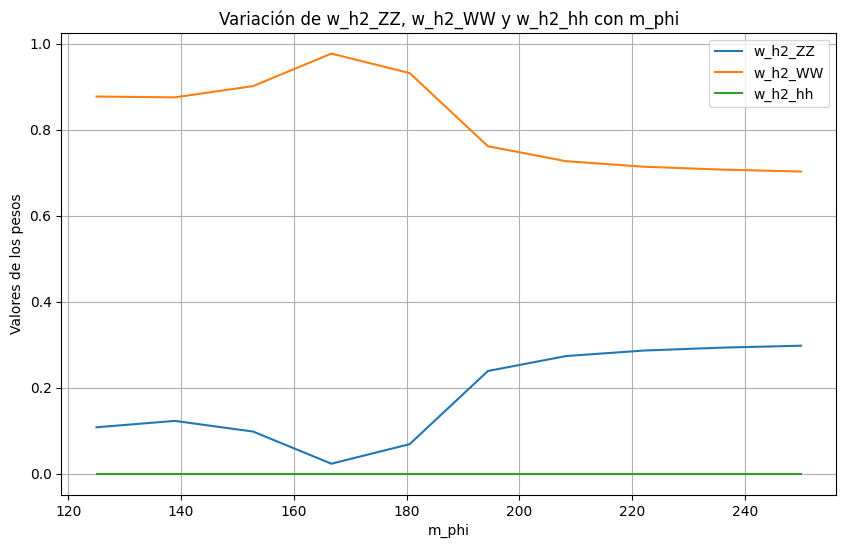

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# [125.0, 250.0, 0.005, -1.6, -20.0, -20.0, 20.0]
# Valores fijos
mA = 300
alpha = -0.001
beta = 1.1025083157700855
lambda6 = -25.0
lambda7 = 20.0
m12 = (1000 / (4 * np.pi) ) * np.sqrt(lambda7) # https://arxiv.org/pdf/2001.00069, A special caso phi -> gaga section

# Definir un rango para m_phi
m_phi_vals = np.linspace(125, 250, 10)  # Rango y cantidad de puntos de ejemplo

# Listas para almacenar los valores que extraemos del diccionario
w_h2_ZZ = []
w_h2_WW = []
w_h2_hh = []

# Iteramos sobre los valores de m_phi y ejecutamos run_oracle
for m_phi in m_phi_vals:
    # Preparamos los parámetros en el orden esperado:
    # [m_phi, mA, alpha, beta, lambda6, lambda7, m12]
    params = [m_phi, mA, alpha, beta, lambda6, lambda7, m12]
    resultado = run_oracle(params)
    total_w = resultado.get("w_total_h2") 
    
    print(total_w) # agregar un catch cuando esto sea None

    # Extraemos los valores del diccionario y los almacenamos
    w_h2_ZZ.append(resultado.get("w_h2_ZZ")/total_w  )
    w_h2_WW.append(resultado.get("w_h2_WW")/total_w  )
    w_h2_hh.append(resultado.get("w_h2_hh")/total_w  )

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(m_phi_vals, w_h2_ZZ, label="w_h2_ZZ")
plt.plot(m_phi_vals, w_h2_WW, label="w_h2_WW")
plt.plot(m_phi_vals, w_h2_hh, label="w_h2_hh")
plt.xlabel("m_phi")
plt.ylabel("Valores de los pesos")
plt.title("Variación de w_h2_ZZ, w_h2_WW y w_h2_hh con m_phi")
plt.legend()
plt.grid(True)
plt.show()
